# Exhibit: Return Predictability — Did It Hold Up?

*Workshop 2 exhibit — **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

## 1. The relation — and the debate

Can stock-market returns be predicted? The most-studied candidate predictor is the **dividend–price ratio**: when prices are low relative to dividends, subsequent returns tend to be high. The workhorse **predictive regression** is

$$r_{t+1} = a + b \, \log(D_t/P_t) + \text{error}_{t+1},$$

where $r_{t+1}$ is next year's stock return and $D_t/P_t$ is this year's dividend–price ratio. The stakes are large: $b \ne 0$ says expected returns move over time — a cornerstone question for asset pricing, market efficiency, and anyone deciding when to invest.

By the late 1980s, a string of influential studies had reported exactly that: high $D/P$ predicts high returns. A consensus formed — returns are predictable. Then **Welch and Goyal (2008)** re-examined the entire roster of proposed predictors and asked a sharper question: *would this predictability actually have helped an investor in real time?* They evaluated every predictor **in sample** (how well does it fit the data we have?) and **out of sample** (how well does it forecast, using only information available at the time?), always against the simplest possible benchmark: a forecast equal to the **historical mean** of returns. Their answer: most predictors perform poorly — unstable in sample, and no better than the historical mean out of sample.

This notebook re-creates their logic with the dividend–price ratio.

**Data:** annual US data, 1927–2021 — S&P index prices and dividends from Robert Shiller's long-run dataset. `ret_next` is next year's total nominal return (%), `log_dp` this year's log dividend–price ratio.

**A deliberate simplification — read before you build on this.** This is a *starting point, not a finished specification*: we use nominal returns (Welch and Goyal study the **equity premium** — returns in excess of the risk-free rate), annual data, and a single predictor. Upgrading the simplification that matters for your question is part of the work — and often part of the contribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

def load(name):
    try:
        df = pd.read_csv(f"../data/{name}", index_col="year")
    except FileNotFoundError:
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="year")
    return df

rp = load("return_predictability.csv").dropna()
rp.tail(3)

,dp,log_dp,ret_next,infl_next,real_ret_next
year,,,,,
2019,0.018333,-3.999041,18.158162,0.013620,16.570466
2020,0.015771,-4.149581,28.139989,0.070364,19.716270
2021,0.012920,-4.348994,-14.877125,0.064544,-20.038182


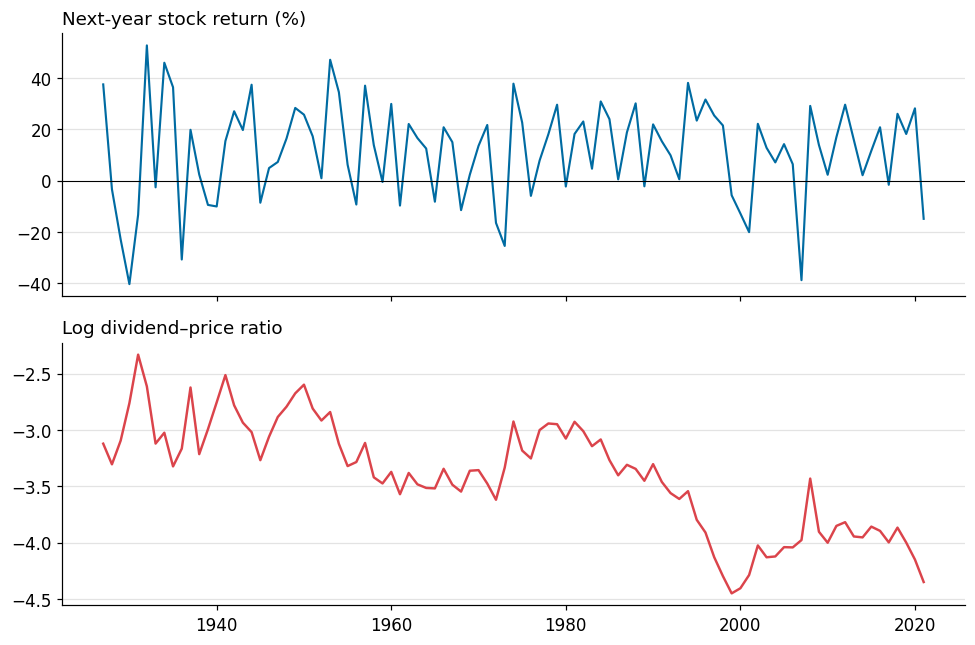

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(rp.index, rp["ret_next"], color=BLUE, lw=1.4)
axes[0].axhline(0, color="black", lw=0.7)
axes[0].set_title("Next-year stock return (%)")
axes[1].plot(rp.index, rp["log_dp"], color=RED, lw=1.6)
axes[1].set_title("Log dividend\u2013price ratio")
plt.tight_layout()
plt.show()

## 2. The view from 1990

Put yourself in 1990, when the predictability consensus formed. Estimate the regression on the postwar sample, as many studies then did:

In [3]:
def fit_rp(d):
    y = d["ret_next"]
    X = sm.add_constant(d["log_dp"])
    return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})

consensus = fit_rp(rp.loc[1941:1990])
print(f"Sample: 1941\u20131990  (n = {int(consensus.nobs)})")
print(consensus.summary().tables[1])
print(f"\nR-squared: {consensus.rsquared:.3f}")

Sample: 1941–1990  (n = 50)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         98.0101     18.968      5.167      0.000      60.833     135.187
log_dp        26.5843      5.942      4.474      0.000      14.939      38.230

R-squared: 0.212


Strong and highly significant: $\hat{b} \approx 27$ (p < 0.001), R² ≈ 0.21 — a fifth of next year's return variation "explained" by this year's dividend–price ratio. In 1990, the evidence said: **returns are predictable.**

Welch and Goyal's question: **did it hold up?** We give it three tests: more data, out-of-sample forecasting, and a look at the mechanism.

## 3. Test 1 — more data (in sample)

The simplest test first: re-estimate with the thirty years of data that arrived after 1990 — and check the stability across subperiods. **Change the splits** (edit the dictionary, rerun) and see how fragile the in-sample evidence is.

In [4]:
SUBSAMPLES = {
    "Full 1927\u20132021": (1927, 2021),
    "1927\u20131956":      (1927, 1956),
    "1957\u20131990":      (1957, 1990),
    "1991\u20132021":      (1991, 2021),
}

rows = []
for name, (start, end) in SUBSAMPLES.items():
    r = fit_rp(rp.loc[start:end])
    rows.append({"sample": name, "b": r.params["log_dp"], "se(b)": r.bse["log_dp"],
                 "p(b)": r.pvalues["log_dp"], "R2": r.rsquared, "n": int(r.nobs)})
pd.DataFrame(rows).round(3)

,sample,b,se(b),p(b),R2,n
0,Full 1927–2021,6.264,4.449,0.159,0.026,95
1,1927–1956,12.547,11.872,0.291,0.020,30
2,1957–1990,37.696,9.840,0.000,0.240,34
3,1991–2021,28.880,9.629,0.003,0.196,31


The 1990 consensus does not survive more data: over the **full sample** the estimate collapses to $\hat{b} \approx 6$, insignificant, R² = 0.03. And across subperiods $\hat{b}$ jumps around — the in-sample evidence is **unstable**. (A formal break test finds no statistically significant breaks here at standard settings: with only 95 annual observations, *detecting* instability is hard — a point we return to in Workshop 3.)

## 4. Test 2 — out of sample: the Welch–Goyal comparison

In-sample fit uses the whole sample to estimate the relationship — including data an investor in real time could never have seen. The **out-of-sample** test imposes the real-time rule: *to forecast year $t$, you may only use data through year $t-1$.*

We let two forecasters compete, each re-estimating every year on all data available so far:

1. **The D/P model**: forecast $= \hat{a} + \hat{b} \log(D/P)$, with $(\hat{a}, \hat{b})$ estimated on data through the previous year.
2. **The historical mean**: forecast $=$ the average return up to the previous year. This is the "no predictability" benchmark — if returns are unpredictable, you cannot beat it.

We compare them over 1991–2021 — the years *after* the consensus formed — with two measures:

- the **RMSE** of each forecaster's errors;
- the **out-of-sample R²**: $\;R^2_{OOS} = 1 - SSE_{model} / SSE_{mean}$. Positive means the model beats the historical mean; **negative means the model forecasts worse than knowing nothing about predictability.**

In [5]:
OOS_START = 1991  # first forecast year — try 1980, or 1966

records = []
for year in rp.index[rp.index >= OOS_START]:
    past = rp.loc[:year - 1]                       # only data available before year t
    r = sm.OLS(past["ret_next"], sm.add_constant(past["log_dp"])).fit()
    records.append({
        "year": year,
        "actual": rp.loc[year, "ret_next"],
        "fc_model": r.params.iloc[0] + r.params.iloc[1] * rp.loc[year, "log_dp"],
        "fc_mean": past["ret_next"].mean(),
    })
oos = pd.DataFrame(records).set_index("year")
oos["se_model"] = (oos["actual"] - oos["fc_model"]) ** 2
oos["se_mean"] = (oos["actual"] - oos["fc_mean"]) ** 2

rmse_model = np.sqrt(oos["se_model"].mean())
rmse_mean = np.sqrt(oos["se_mean"].mean())
oos_r2 = 1 - oos["se_model"].sum() / oos["se_mean"].sum()
print(f"Out-of-sample {OOS_START}\u20132021  (n = {len(oos)})")
print(f"RMSE, D/P model:       {rmse_model:.2f}")
print(f"RMSE, historical mean: {rmse_mean:.2f}")
print(f"Out-of-sample R2:      {oos_r2:+.3f}")

Out-of-sample 1991–2021  (n = 31)
RMSE, D/P model:       17.29
RMSE, historical mean: 16.76
Out-of-sample R2:      -0.064


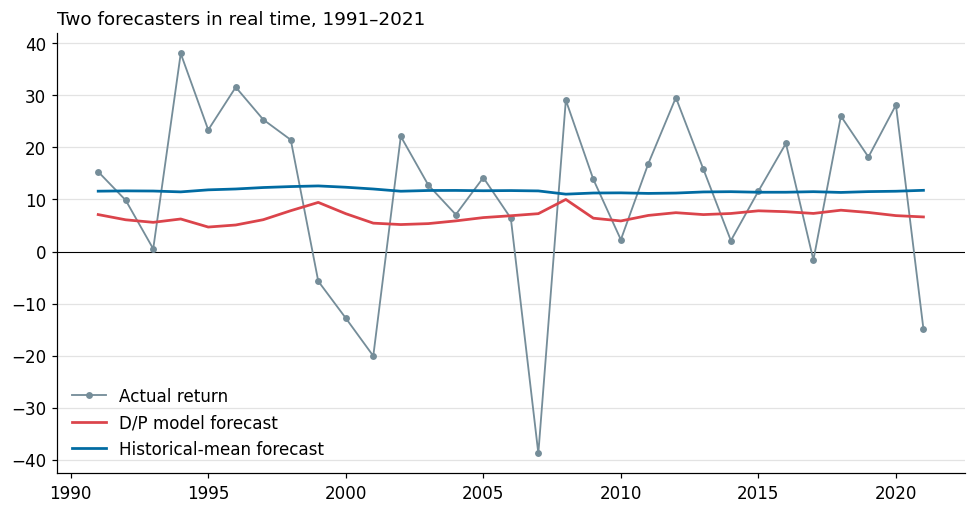

In [6]:
# Figure 1: what each forecaster predicted, against what happened
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhline(0, color="black", lw=0.7)
ax.plot(oos.index, oos["actual"], color=GREY, lw=1.2, marker="o", ms=3.5, label="Actual return")
ax.plot(oos.index, oos["fc_model"], color=RED, lw=1.8, label="D/P model forecast")
ax.plot(oos.index, oos["fc_mean"], color=BLUE, lw=1.8, label="Historical-mean forecast")
ax.set_title(f"Two forecasters in real time, {OOS_START}\u20132021")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Look at the two forecast lines before comparing errors: the historical mean barely moves — it forecasts roughly the same return every year. The D/P model moves with the ratio — and through the 1990s, with $D/P$ at historic lows, it kept forecasting *low* returns while the market boomed.

The single-picture comparison is Welch and Goyal's signature device: the **cumulative difference in squared errors** — the historical mean's squared error minus the model's, accumulated year by year. When the line **rises, the model is winning**; when it **falls, the historical mean is winning**; where it ends tells you who won overall.

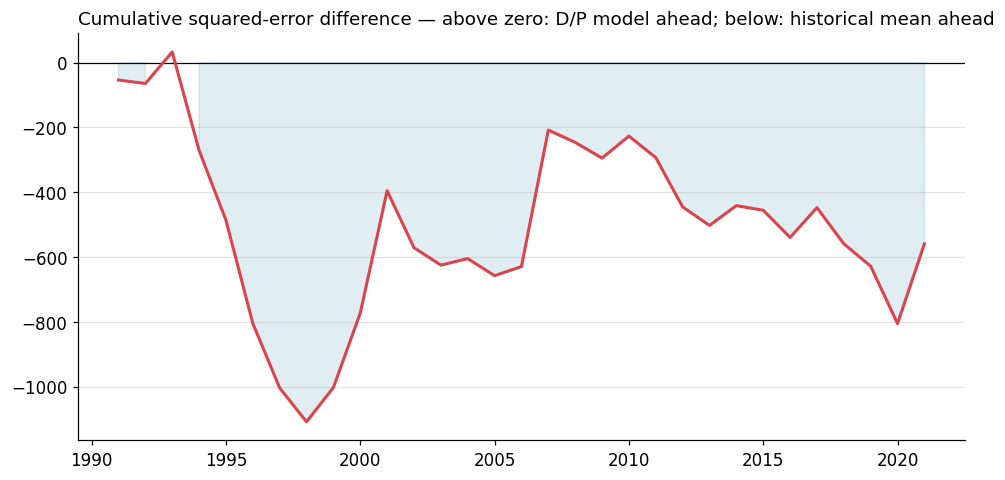

In [7]:
# Figure 2: the Welch-Goyal comparison plot
cumdiff = (oos["se_mean"] - oos["se_model"]).cumsum()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color="black", lw=0.8)
ax.plot(cumdiff.index, cumdiff, color=RED, lw=2)
ax.fill_between(cumdiff.index, 0, cumdiff, where=(cumdiff >= 0), color=RED, alpha=0.12)
ax.fill_between(cumdiff.index, 0, cumdiff, where=(cumdiff < 0), color=BLUE, alpha=0.12)
ax.set_title("Cumulative squared-error difference — above zero: D/P model ahead; below: historical mean ahead")
plt.tight_layout()
plt.show()

**The verdict:** out-of-sample R² ≈ **−0.06** — the model that looked so convincing in 1990 forecast *worse* than the naive historical mean over the next thirty years. **Try `OOS_START` = 1980 or 1966** and rerun: at best, the out-of-sample gain is roughly zero.

This — replicated across dozens of predictors — is the main message of **Welch and Goyal (2008)**: in-sample fit systematically overstates what a real-time forecaster could have achieved; against the humble historical mean, the predictors do not deliver.

## 5. Test 3 — why? The mechanism

How can a relationship fit so well in sample and fail so badly in real time? A clue: check the **level** of the predictor across periods. Run the next cell.

In [8]:
# The average level of log(D/P) in each subsample
for name, (start, end) in SUBSAMPLES.items():
    print(name, round(rp.loc[start:end, "log_dp"].mean(), 2))

Full 1927–2021 -3.4
1927–1956 -2.94
1957–1990 -3.29
1991–2021 -3.96


The dividend–price ratio's average level **shifted down** across the periods — most dramatically from the 1990s (look again at the ratio's plot in Section 1). And here is the twist: *within* each period, the slope remains strong — the subsample table above shows $\hat{b} \approx 29$ with R² ≈ 0.20 for 1991–2021 alone. Lettau and Van Nieuwerburgh (2008) read the evidence this way: the relation holds within regimes, but the ratio's *steady state* shifts between them.

So both sides of the debate are right — about different things:

- **Ex post**, knowing where the level shifts were, predictability is there within regimes.
- **Ex ante**, in real time, it is unusable: the model keeps forecasting off the *old* level — exactly what Figure 1 showed through the 1990s.

**Structural change is the hinge between in-sample and out-of-sample performance.** A relationship that shifts can look strong in the rear-view mirror and still be worthless through the windshield.

## 6. What could a paper deliver?

You have now seen that the relation is not stable — and what that does to real-time forecasting. **That, by itself, is not yet a research question.** "Is X stable? — No" is a finding, not a paper. The interesting paper starts with what you build *on top of* the finding. Four types of questions you can build:

1. **Timing / episodes** — when did the dividend–price ratio's level shift, and what changed in markets then? (Share repurchases replacing dividends? The 1990s boom?)
2. **Source / mechanism** — is the instability in the *predictor* (the ratio's steady state) or in the *relation* (the slope)? Those are different papers.
3. **Interpretation / inference** — what do full-sample tests of predictability test when levels shift? And what is a break test worth when 95 observations cannot detect the instability you can see?
4. **Consequences / practice** — can anything rescue the real-time investor: rolling estimation, detecting the shifts, forecast combination (Rapach, Strauss and Zhou 2010)? Or is the Welch–Goyal verdict final?

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*. Compare (on a relation that is *not* one of today's exhibits):

> *Weak:* "This paper examines whether Okun's law is stable."
>
> *Strong:* "This paper shows that Okun's law held in every US recession since 1960 except 2020, and asks what made the COVID labor market different."

The strong version states a deliverable and why it is interesting — even before the analysis exists.

**Your task (in class):** write one or two **"This paper…"** sentences for this exhibit. Be specific: what does your paper show, ask, or deliver?

## 7. Further reading

If this exhibit grabbed you, start here:

- Welch, I., and Goyal, A. (2008). "A Comprehensive Look at the Empirical Performance of Equity Premium Prediction." *Review of Financial Studies*, 21(4) — the paper this exhibit re-creates in miniature.
- Lettau, M., and Van Nieuwerburgh, S. (2008). "Reconciling the Return Predictability Evidence." *Review of Financial Studies*, 21(4) — steady-state shifts in the dividend–price ratio as the resolution.
- Paye, B., and Timmermann, A. (2006). "Instability of Return Prediction Models." *Journal of Empirical Finance*, 13(3) — structural-break tests applied to exactly this regression.
- Farmer, L., Schmidt, L., and Timmermann, A. (2023). "Pockets of Predictability." *Journal of Finance*, 78(3) — predictability as a local, episodic phenomenon.
- Rapach, D., Strauss, J., and Zhou, G. (2010). "Out-of-Sample Equity Premium Prediction." *Review of Financial Studies*, 23(2) — can combining forecasts rescue predictability?